In [7]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
!gdown 19W-SCn-b7a7BQ6XEOk4Yaey7FLELqlV8

Downloading...
From: https://drive.google.com/uc?id=19W-SCn-b7a7BQ6XEOk4Yaey7FLELqlV8
To: /content/loan.csv
100% 9.16k/9.16k [00:00<00:00, 19.4MB/s]


In [9]:
df = pd.read_csv('loan.csv')
df.shape

(200, 3)

In [10]:
df.head()
#binary classification

,x1,x2,y
0,3.729417,6.694052,rejected
1,6.282660,1.952843,approved
2,5.524101,2.296845,approved
3,-0.248258,5.732238,rejected
4,1.738760,4.701953,rejected


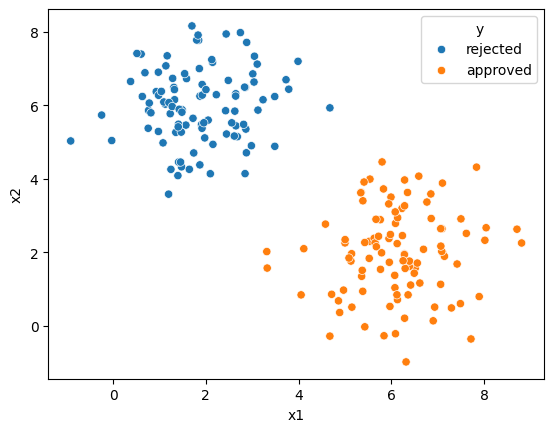

In [11]:
sns.scatterplot(x='x1',y='x2',data=df,hue='y')
plt.show()

In [ ]:
#Line equation & Distance function

# line = 2x1+3x2=8=0
#data point = [1.7,4.7]
d=(w^T*x+w0)/|w\

In [12]:
def dist_from_hyperplane(w,w0,x):
  return (np.dot(w.T,x)+w0/np.linalg.norm(w))

In [13]:
df.head()

,x1,x2,y
0,3.729417,6.694052,rejected
1,6.282660,1.952843,approved
2,5.524101,2.296845,approved
3,-0.248258,5.732238,rejected
4,1.738760,4.701953,rejected


In [14]:
def transform(x):
  if x=='rejected':
    return 1
  return -1


#label encoding
df['y']=df['y'].apply(transform)
df.head()

,x1,x2,y
0,3.729417,6.694052,1
1,6.282660,1.952843,-1
2,5.524101,2.296845,-1
3,-0.248258,5.732238,1
4,1.738760,4.701953,1


In [15]:
#preparing feature matrix and label vector
X=df.drop('y',axis=1).values
Y=df['y'].values

In [17]:
X[:5]

array([[ 3.72941743,  6.69405227],
       [ 6.28266031,  1.95284309],
       [ 5.52410061,  2.29684453],
       [-0.24825777,  5.73223814],
       [ 1.73875952,  4.70195336]])

In [18]:
Y[:5]

array([ 1, -1, -1,  1,  1])

In [28]:
#Random Initializing the line
w=np.random.normal(size=(2,))
w0=np.random.normal()

In [29]:
x1=np.array([0,8])
x2=(-w[0]*x1-w0)/w[1]

In [30]:
x2

array([0.03369856, 1.78250649])

[]

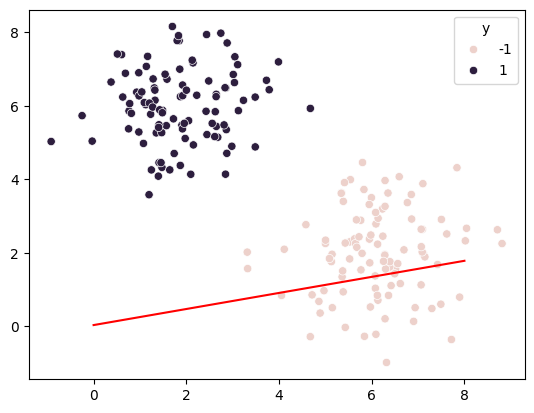

In [31]:
plt.plot(x1,x2,'r')
sns.scatterplot(x=X[:,0],y=X[:,1],data=df,hue='y')
plt.plot()

In [32]:
def show(w,w0,X,Y):
  x1=np.array([0,8])
  x2=(-w[0]*x1-w0)/w[1]
  plt.plot(x1,x2,'r')
  sns.scatterplot(x=X[:,0],y=X[:,1],data=df,hue='y')
  plt.show()
#Reusable function -


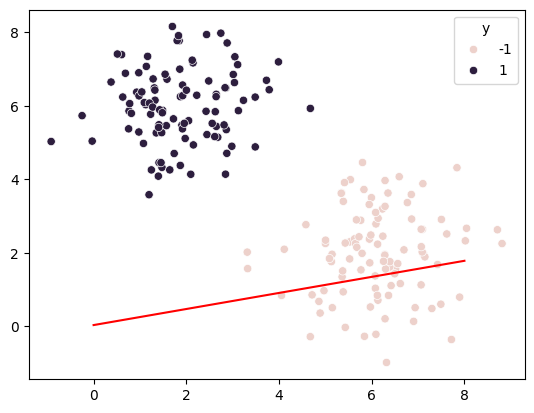

In [33]:
show(w,w0,X,Y)

In [34]:
def perceptron_training(X,y,w,w0,num_iter=100):
  for itr in range(num_iter):
    for i in range(X.shape[0]):
      xi=X[i]
      yi=y[i]
      d=dist_from_hyperplane(w,w0,xi)
      pred_sign=np.sign(d)

      if pred_sign!=yi:
        w=w+(xi*yi)
        w0=w0+yi
  return w,w0



In [36]:
w_best,w0_best=perceptron_training(X,Y,w,w0)

In [37]:
w_best,w0_best

(array([-4.92457383,  4.49051608]), np.float64(-0.05868287127269767))

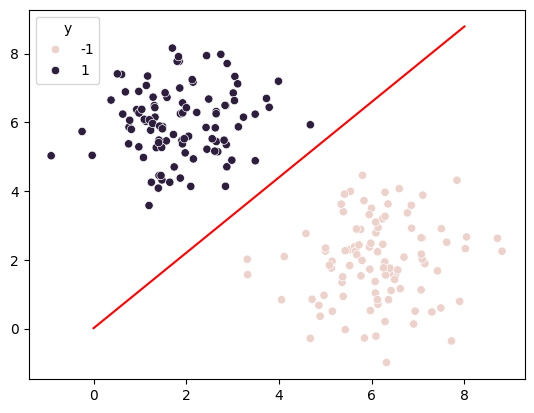

In [38]:
show(w_best,w0_best,X,Y)

In [41]:
def perceptron_training(X,y,w,w0,num_iter=100):
  for itr in range(num_iter):
    print("Iteration Number:",itr)
    misscl=0
    for i in range(X.shape[0]):
      xi=X[i]
      yi=y[i]
      d=dist_from_hyperplane(w,w0,xi)
      pred_sign=np.sign(d)

      if pred_sign!=yi:
        misscl+=1
        #this is misclassified points
        #this is my update equation
        w=w+(xi*yi)
        w0=w0+yi
    print("Total Misclassified points:",misscl)
    if misscl==0:
      return w,w0

  return w,w0



In [42]:
w_best,w0_best=perceptron_training(X,Y,w,w0)

Iteration Number: 0
Total Misclassified points: 2
Iteration Number: 1
Total Misclassified points: 0
